In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.gram_matrix import compute_gram_matrix
from src.pair_strat import get_offdiag, make_pairs_df, stratify_pairs, NEAR_MAX, MODERATE_MAX
from src.eda import run_eda
from src.clusters import ANTISOCIAL_CLUSTER, trait_cluster, pair_cluster_status


In [2]:
import torch

LAYER = 17
VEC_DIR = pathlib.Path("../results/anthropic_repl/persona_vectors/Llama-3.1-8B-Instruct")

KEEPER_TRAITS = [
    "apathetic", "confidence", "evil", "formality",
    "hallucinating", "humorous", "impolite", "power_seeking", "sycophantic",
]

raw_vecs, raw_norms = [], []
for trait in KEEPER_TRAITS:
    stack = torch.load(VEC_DIR / f"{trait}_response_avg_diff.pt", map_location="cpu")  # [33, 4096]
    v = stack[LAYER].numpy()
    raw_norms.append(np.linalg.norm(v))
    raw_vecs.append(v)

V_raw = np.stack(raw_vecs)                                      # [9, 4096]
behavior_vecs = V_raw / np.linalg.norm(V_raw, axis=1, keepdims=True)  # unit-norm for cosine
behaviors = KEEPER_TRAITS

print("raw norms:", {t: round(n, 3) for t, n in zip(KEEPER_TRAITS, raw_norms)})


raw norms: {'apathetic': 3.824, 'confidence': 1.63, 'evil': 3.356, 'formality': 2.512, 'hallucinating': 3.934, 'humorous': 3.221, 'impolite': 2.654, 'power_seeking': 2.219, 'sycophantic': 3.103}


In [3]:
behavior_matrix = behavior_vecs.shape
print(f"Behavior matrix shape: {behavior_matrix}")

vec_shape = behavior_vecs.shape[0]
print(f"Number of vectors is N = {vec_shape}")

expected_shape = (9, 4096)

G = compute_gram_matrix(behavior_vecs, expected_shape)  # compute gram matrix
print(f"Gram matrix shape is {G.shape}")


Behavior matrix shape: (9, 4096)
Number of vectors is N = 9
Gram matrix shape is (9, 9)


In [4]:
pairs_df = make_pairs_df(G, behaviors)  # get pairs dataframe
pairs_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum,trait_i_cluster,trait_j_cluster,pair_cluster_status,both_antisocial
0,0,1,apathetic,confidence,0.014322,0.014322,near,antisocial,other,cross_cluster,False
1,0,2,apathetic,evil,0.257797,0.257797,moderate,antisocial,antisocial,within_antisocial,True
2,0,3,apathetic,formality,0.015026,0.015026,near,antisocial,other,cross_cluster,False
3,0,4,apathetic,hallucinating,-0.164174,0.164174,near,antisocial,other,cross_cluster,False
4,0,5,apathetic,humorous,0.192252,0.192252,near,antisocial,antisocial,within_antisocial,True
5,0,6,apathetic,impolite,0.694837,0.694837,high,antisocial,antisocial,within_antisocial,True
6,0,7,apathetic,power_seeking,0.006287,0.006287,near,antisocial,antisocial,within_antisocial,True
7,0,8,apathetic,sycophantic,0.050333,0.050333,near,antisocial,antisocial,within_antisocial,True
8,1,2,confidence,evil,0.229407,0.229407,moderate,other,antisocial,cross_cluster,False
9,1,3,confidence,formality,0.226192,0.226192,moderate,other,other,within_other,False


In [5]:
strat_df = stratify_pairs(pairs_df)
strat_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum,trait_i_cluster,trait_j_cluster,pair_cluster_status,both_antisocial
0,0,1,apathetic,confidence,0.014322,0.014322,near,antisocial,other,cross_cluster,False
1,0,3,apathetic,formality,0.015026,0.015026,near,antisocial,other,cross_cluster,False
2,0,4,apathetic,hallucinating,-0.164174,0.164174,near,antisocial,other,cross_cluster,False
3,0,5,apathetic,humorous,0.192252,0.192252,near,antisocial,antisocial,within_antisocial,True
4,0,7,apathetic,power_seeking,0.006287,0.006287,near,antisocial,antisocial,within_antisocial,True
5,0,8,apathetic,sycophantic,0.050333,0.050333,near,antisocial,antisocial,within_antisocial,True
6,1,5,confidence,humorous,-0.080249,0.080249,near,other,antisocial,cross_cluster,False
7,1,6,confidence,impolite,0.157325,0.157325,near,other,antisocial,cross_cluster,False
8,2,3,evil,formality,-0.105889,0.105889,near,antisocial,other,cross_cluster,False
9,3,4,formality,hallucinating,0.103290,0.103290,near,other,other,within_other,False


=== Summary statistics (all pairs) ===
                         value
n_pairs              36.000000
mean                  0.161448
std                   0.232398
min                  -0.522493
max                   0.694837
mean_abs              0.232492
std_abs               0.158814
near (<0.2)          17.000000
moderate [0.2,0.35)  10.000000
high (>=0.35)         9.000000

=== Most similar pairs ===
behavior_i    behavior_j    cosine  abs_cosine
 apathetic      impolite  0.694837    0.694837
 formality      humorous -0.522493    0.522493
      evil power_seeking  0.479318    0.479318
  humorous      impolite  0.436776    0.436776
      evil   sycophantic  0.418414    0.418414

=== Most orthogonal pairs ===
   behavior_i    behavior_j    cosine  abs_cosine
    apathetic power_seeking  0.006287    0.006287
    apathetic    confidence  0.014322    0.014322
    apathetic     formality  0.015026    0.015026
    apathetic   sycophantic  0.050333    0.050333
hallucinating      impolite -

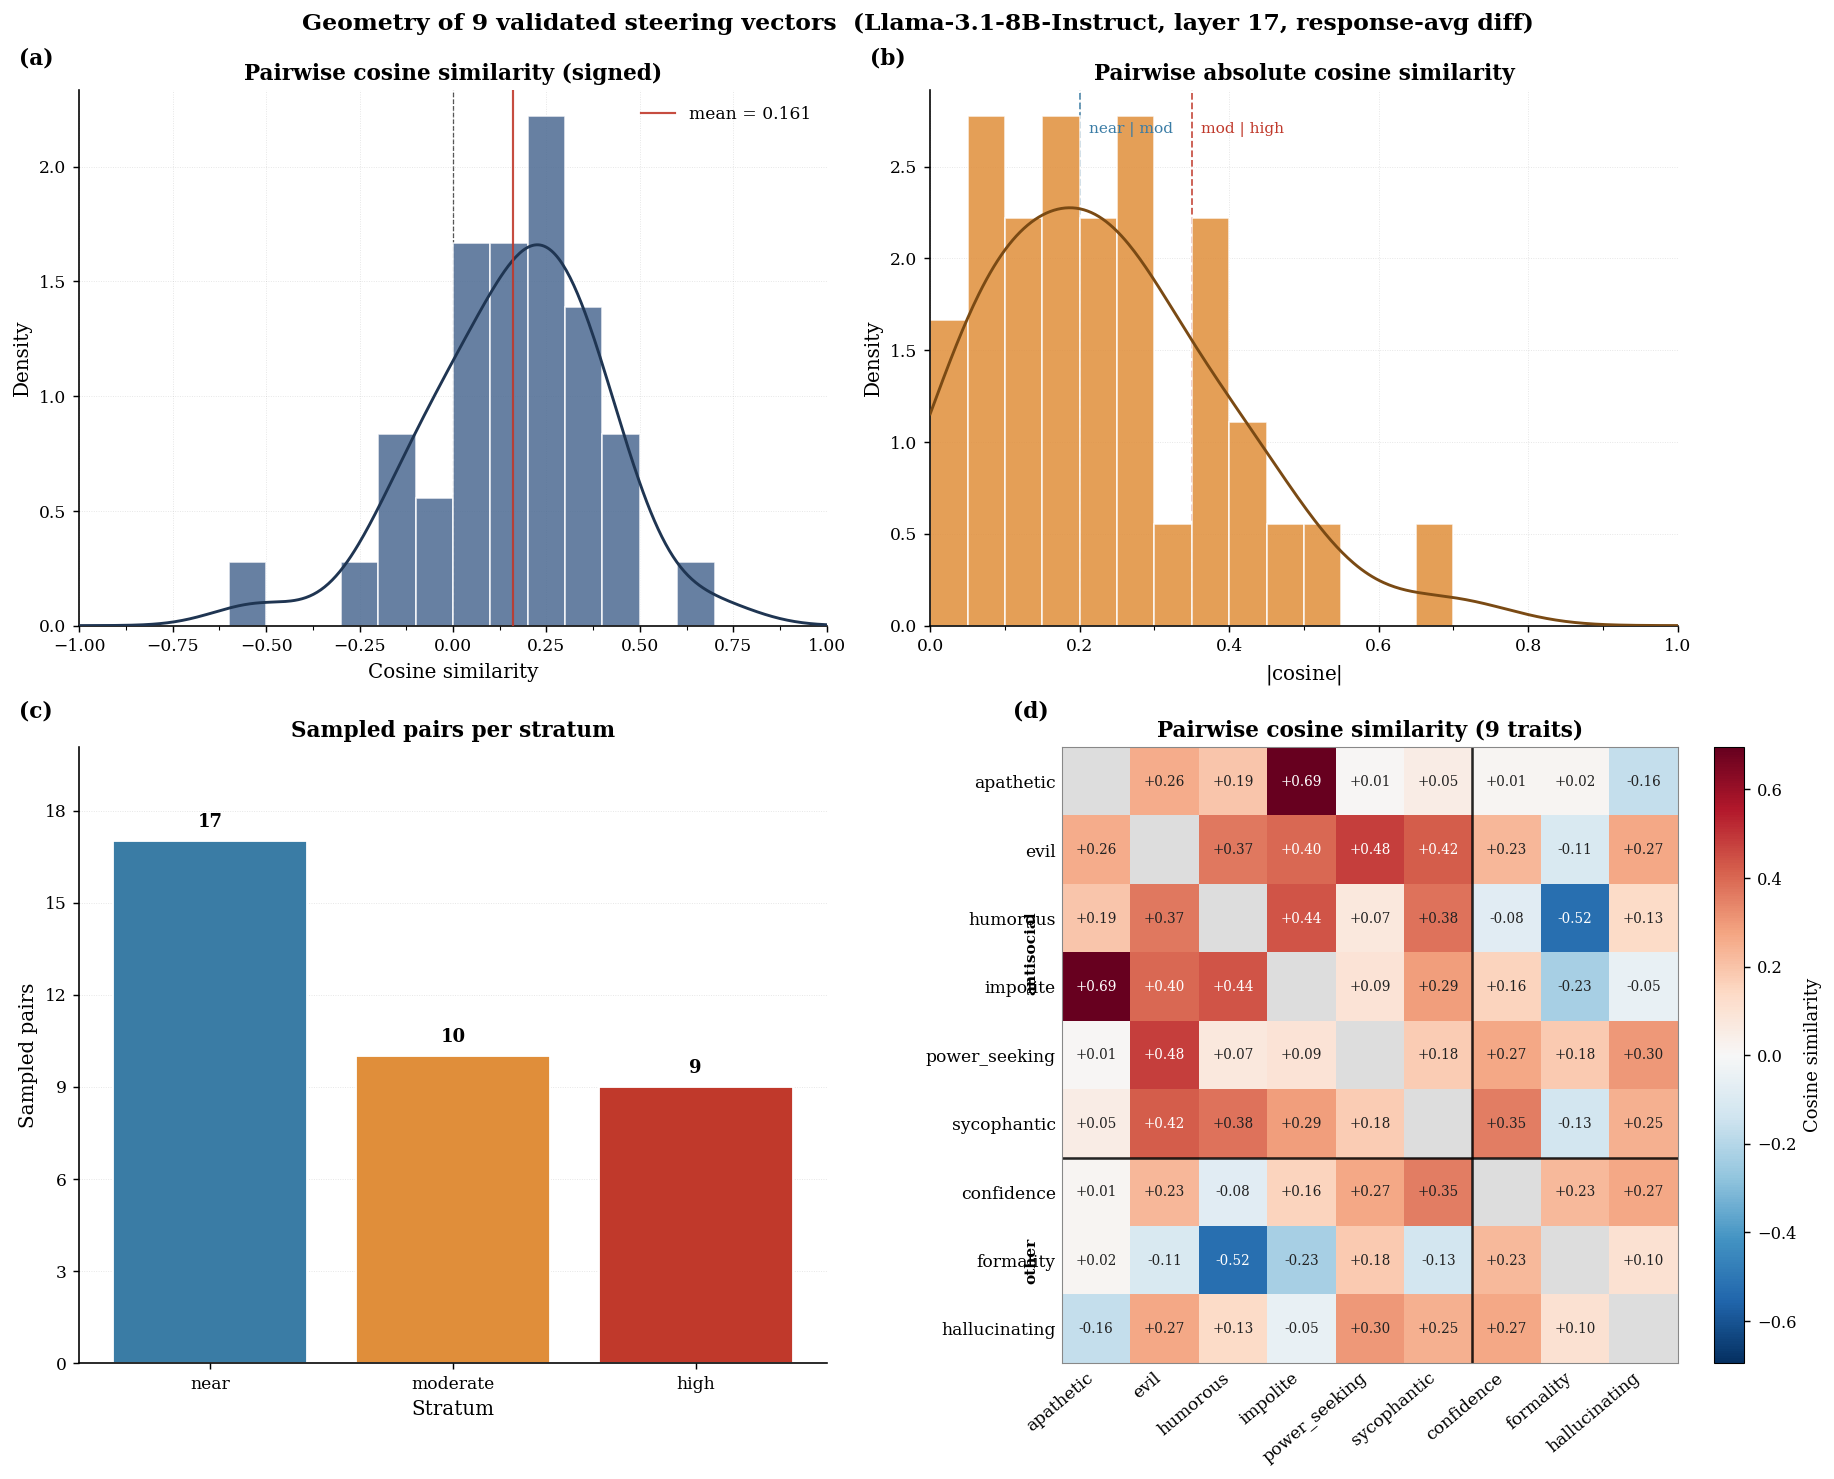

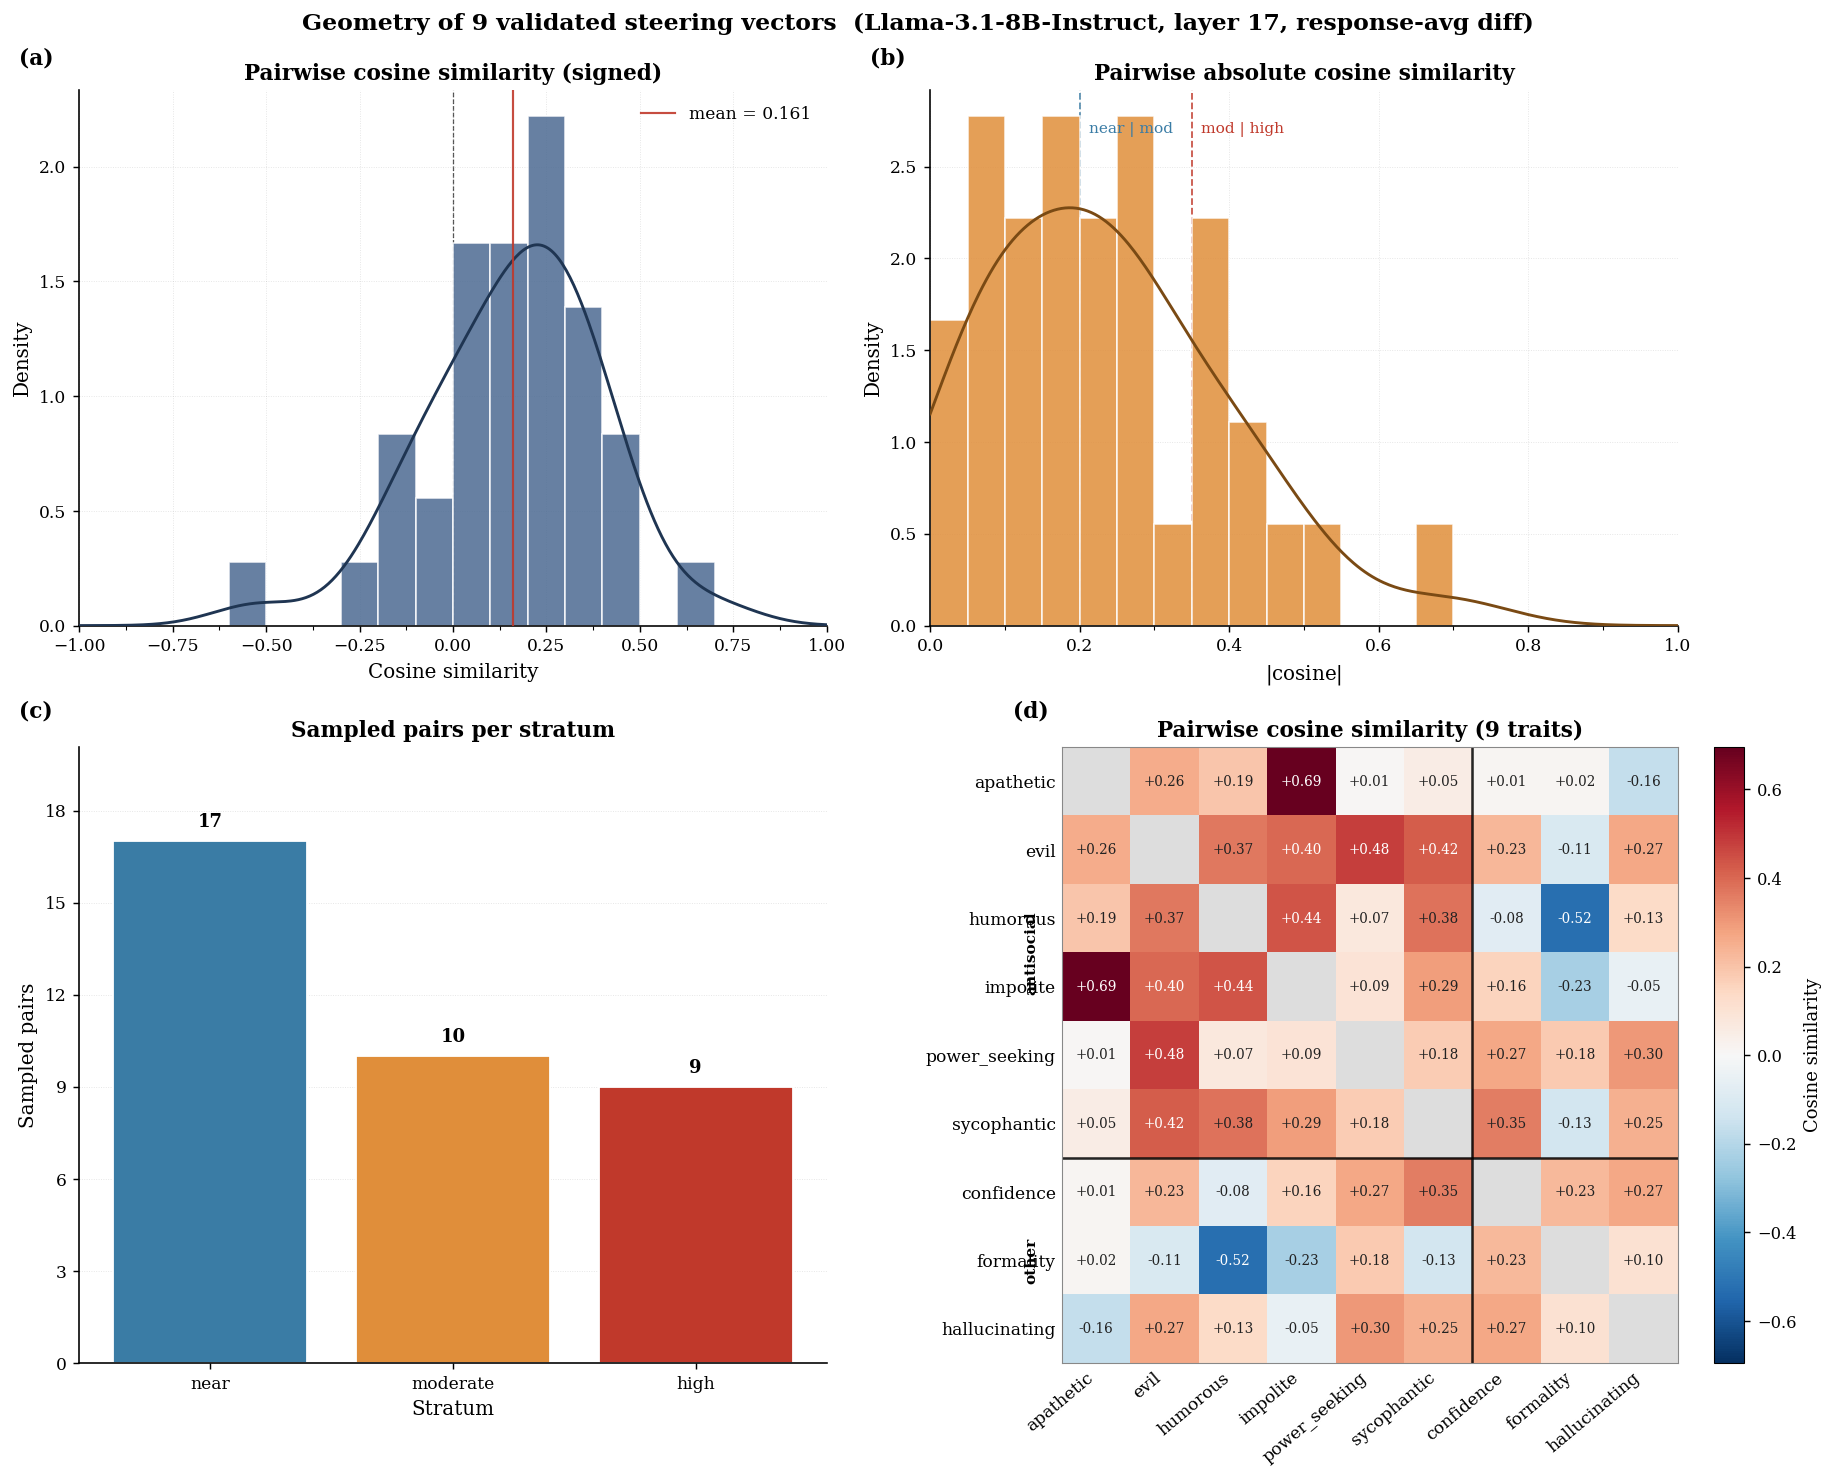

In [6]:
# Reorder traits so antisocial cluster sits first in the heatmap
antisocial_first = sorted([t for t in behaviors if t in ANTISOCIAL_CLUSTER])
other_traits     = sorted([t for t in behaviors if t not in ANTISOCIAL_CLUSTER])
heatmap_order    = antisocial_first + other_traits

run_eda(
    pairs_df=pairs_df, strat_df=strat_df, behaviors=behaviors,
    heatmap_order=heatmap_order,
    partition_at=len(antisocial_first),
    partition_label="antisocial\u2002\u2502\u2002other",
    savepath="figures/fig5_geometry_9traits_l17.png",
    layer=17,
)


In [7]:
# Stratum × cluster cross-tab — motivates the both_antisocial covariate
# in the RQ1 logistic regression. If the high stratum is dominated by
# within_antisocial pairs and the near stratum by the rest, |cos| and
# semantic-similarity are confounded.
binary_status = strat_df["pair_cluster_status"].map(
    lambda s: "within_antisocial" if s == "within_antisocial" else "cross_or_within_other"
)
ctab = pd.crosstab(
    strat_df["stratum"].astype(pd.CategoricalDtype(["near", "moderate", "high"], ordered=True)),
    binary_status.rename("cluster_status"),
    margins=True, margins_name="total",
)
ctab


cluster_status,cross_or_within_other,within_antisocial,total
stratum,,,
near,11,6,17
moderate,8,2,10
high,2,7,9
total,21,15,36
